# 🏦 Globe Bank International
## Customer Retention Analysis
### Stage 1 — Project Setup & Data Exploration

| Detail | Description |
|--------|-------------|
| **Dataset** | Credit Card Customers Prediction (Kaggle) |
| **Source** | https://leaps.analyttica.com/home |
| **Tools** | Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly |
| **Objective** | Understand the data structure and identify early patterns in customer attrition |
| **Author** | Md Moshraf Hossain |
| **Date** | March 2026 |

## 1. Import Libraries
We begin by importing all the libraries we need for this project.
- **Pandas & NumPy** — data loading and manipulation
- **Matplotlib & Seaborn** — static charts and visualisations
- **Plotly** — interactive charts

In [61]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings("ignore")

print("✓ All libraries imported successfully.")

✓ All libraries imported successfully.


## 2. Global Style Settings
We set a consistent colour palette and chart style that will be used 
throughout the entire project.
- 🔵 **Blue** = Retained customers
- 🔴 **Red** = Churned customers

In [62]:
# Consistent colour palette used throughout the entire project
COLOURS = {
    "retained":  "#2E86AB",   # blue  — existing customers
    "churned":   "#E84855",   # red   — attrited customers
    "neutral":   "#A8DADC",   # light blue
    "highlight": "#F4A261",   # orange — accent
}

# Set the default chart style
sns.set_theme(style="whitegrid", palette=[COLOURS["retained"], COLOURS["churned"]])
plt.rcParams.update({
    "figure.dpi":      120,
    "axes.titlesize":  13,
    "axes.labelsize":  11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

print("✓ Style settings applied successfully.")
print(f"  Retained colour : {COLOURS['retained']}")
print(f"  Churned colour  : {COLOURS['churned']}")

✓ Style settings applied successfully.
  Retained colour : #2E86AB
  Churned colour  : #E84855


## 3. Load Data
We load the raw dataset from the `data/raw/` folder.
The dataset contains ~10,000 customers and 23 columns.
We also remove two Naive Bayes classifier columns that came 
with the dataset — they are not useful for our analysis.

In [63]:

# Load the raw dataset
DATA_PATH = "../data/raw/BankChurners.csv"

# Load the data
df = pd.read_csv(DATA_PATH)

# Display the first 5 rows to confirm it worked
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [64]:
# Remove the two Naive Bayes columns that came with the dataset
cols_to_drop = [c for c in df.columns if "Naive_Bayes" in c]
df.drop(columns=cols_to_drop, inplace=True)

print(f"✓ Dataset loaded successfully.")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Dropped : {cols_to_drop}")

✓ Dataset loaded successfully.
  Rows    : 10,127
  Columns : 21
  Dropped : ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


## 4. Data Dictionary
A reference guide for all 21 columns in the dataset.

In [65]:
# Display the data dictionary as a reference table
data_dictionary = {
    "Column": [
        "CLIENTNUM", "Attrition_Flag", "Customer_Age", "Gender",
        "Dependent_count", "Education_Level", "Marital_Status",
        "Income_Category", "Card_Category", "Months_on_book",
        "Total_Relationship_Count", "Months_Inactive_12_mon",
        "Contacts_Count_12_mon", "Credit_Limit", "Total_Revolving_Bal",
        "Avg_Open_To_Buy", "Total_Amt_Chng_Q4_Q1", "Total_Trans_Amt",
        "Total_Trans_Ct", "Total_Ct_Chng_Q4_Q1", "Avg_Utilization_Ratio"
    ],
    "Type": [
        "ID", "Target", "Numeric", "Categorical",
        "Numeric", "Categorical", "Categorical",
        "Categorical", "Categorical", "Numeric",
        "Numeric", "Numeric",
        "Numeric", "Numeric", "Numeric",
        "Numeric", "Numeric", "Numeric",
        "Numeric", "Numeric", "Numeric"
    ],
    "Description": [
        "Unique customer ID — not used in analysis",
        "TARGET: Existing Customer = Retained, Attrited Customer = Churned",
        "Customer age in years",
        "M = Male, F = Female",
        "Number of dependents",
        "Highest education level",
        "Married, Single, Divorced, Unknown",
        "Annual income bracket",
        "Blue, Silver, Gold, Platinum",
        "How long the customer has been with the bank (months)",
        "Number of products held by the customer",
        "Months inactive in the last 12 months",
        "Number of contacts in the last 12 months",
        "Credit card limit",
        "Total revolving balance",
        "Average open-to-buy credit line (last 12 months)",
        "Change in transaction amount (Q4 vs Q1)",
        "Total transaction amount (last 12 months)",
        "Total transaction count (last 12 months)",
        "Change in transaction count (Q4 vs Q1)",
        "Average card utilisation ratio"
    ]
}

dd_df = pd.DataFrame(data_dictionary)
dd_df

,Column,Type,Description
0,CLIENTNUM,ID,Unique customer ID — not used in analysis
1,Attrition_Flag,Target,"TARGET: Existing Customer = Retained, Attrited..."
2,Customer_Age,Numeric,Customer age in years
3,Gender,Categorical,"M = Male, F = Female"
4,Dependent_count,Numeric,Number of dependents
5,Education_Level,Categorical,Highest education level
6,Marital_Status,Categorical,"Married, Single, Divorced, Unknown"
7,Income_Category,Categorical,Annual income bracket
8,Card_Category,Categorical,"Blue, Silver, Gold, Platinum"
9,Months_on_book,Numeric,How long the customer has been with the bank (...


## 🔍 Initial Data Inspection

A first look at the data — reviewing the first few rows, column names, shape, and data types.

In [66]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [67]:
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
print(df.dtypes)

Shape: 10,127 rows × 21 columns

CLIENTNUM                     int64
Attrition_Flag                  str
Customer_Age                  int64
Gender                          str
Dependent_count               int64
Education_Level                 str
Marital_Status                  str
Income_Category                 str
Card_Category                   str
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object


## 🧹 Data Quality Check

In [68]:
# Missing values
missing = df.isnull().sum()
print("=== Missing Values ===")
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found.\n")

=== Missing Values ===
✅ No missing values found.



In [69]:
# Duplicate rows
dupes = df.duplicated().sum()
print(f"\n=== Duplicate Rows ===")
print(f"✅ Duplicates found: {dupes}")


=== Duplicate Rows ===
✅ Duplicates found: 0


In [70]:
# Drop CLIENTNUM
df.drop(columns=["CLIENTNUM"], inplace=True)
print(f"\n✅ CLIENTNUM dropped. New shape: {df.shape}")


✅ CLIENTNUM dropped. New shape: (10127, 20)


## 🎯 Target Variable Overview

In [71]:
# Encode Attrition_Flag to numeric (0 = Retained, 1 = Churned)
df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1,
})

In [72]:
# Readable label column for charts only — never used as a model feature
df["Churn_Label"] = df["Attrition_Flag"].map({0: "Retained", 1: "Churned"})
counts = df["Churn_Label"].value_counts()
pct    = df["Churn_Label"].value_counts(normalize=True) * 100

print("=== Target Variable Distribution ===\n")
for label in ["Retained", "Churned"]:
    print(f"  {label}: {counts[label]:,} customers ({pct[label]:.2f}%)")

=== Target Variable Distribution ===

  Retained: 8,500 customers (83.93%)
  Churned: 1,627 customers (16.07%)


## 📊 Descriptive Statistics

In [73]:
exclude = ["Attrition_Flag", "Churn_Label"]

numeric_cols     = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols     = [c for c in numeric_cols if c not in exclude]

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in exclude]

print(f"Numeric columns ({len(numeric_cols)}):\n  {numeric_cols}\n")
print(f"Categorical columns ({len(categorical_cols)}):\n  {categorical_cols}")

Numeric columns (14):
  ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

Categorical columns (5):
  ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [74]:
df[numeric_cols].describe().round(2)

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,7469.14,0.76,4404.09,64.86,0.71,0.27
std,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,9090.69,0.22,3397.13,23.47,0.24,0.28
min,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00,0.00,0.00
25%,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,1324.50,0.63,2155.50,45.00,0.58,0.02
50%,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3474.00,0.74,3899.00,67.00,0.70,0.18
75%,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,9859.00,0.86,4741.00,81.00,0.82,0.50
max,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,18484.00,139.00,3.71,1.00


In [75]:
for col in categorical_cols:
    print(f"\n=== {col} ===")
    vc  = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    for val in vc.index:
        print(f"  {val:<25} {vc[val]:>5,}  ({pct[val]:.1f}%)")


=== Gender ===
  F                         5,358  (52.9%)
  M                         4,769  (47.1%)

=== Education_Level ===
  Graduate                  3,128  (30.9%)
  High School               2,013  (19.9%)
  Unknown                   1,519  (15.0%)
  Uneducated                1,487  (14.7%)
  College                   1,013  (10.0%)
  Post-Graduate               516  (5.1%)
  Doctorate                   451  (4.5%)

=== Marital_Status ===
  Married                   4,687  (46.3%)
  Single                    3,943  (38.9%)
  Unknown                     749  (7.4%)
  Divorced                    748  (7.4%)

=== Income_Category ===
  Less than $40K            3,561  (35.2%)
  $40K - $60K               1,790  (17.7%)
  $80K - $120K              1,535  (15.2%)
  $60K - $80K               1,402  (13.8%)
  Unknown                   1,112  (11.0%)
  $120K +                     727  (7.2%)

=== Card_Category ===
  Blue                      9,436  (93.2%)
  Silver                      55

## 📊 Churn Distribution

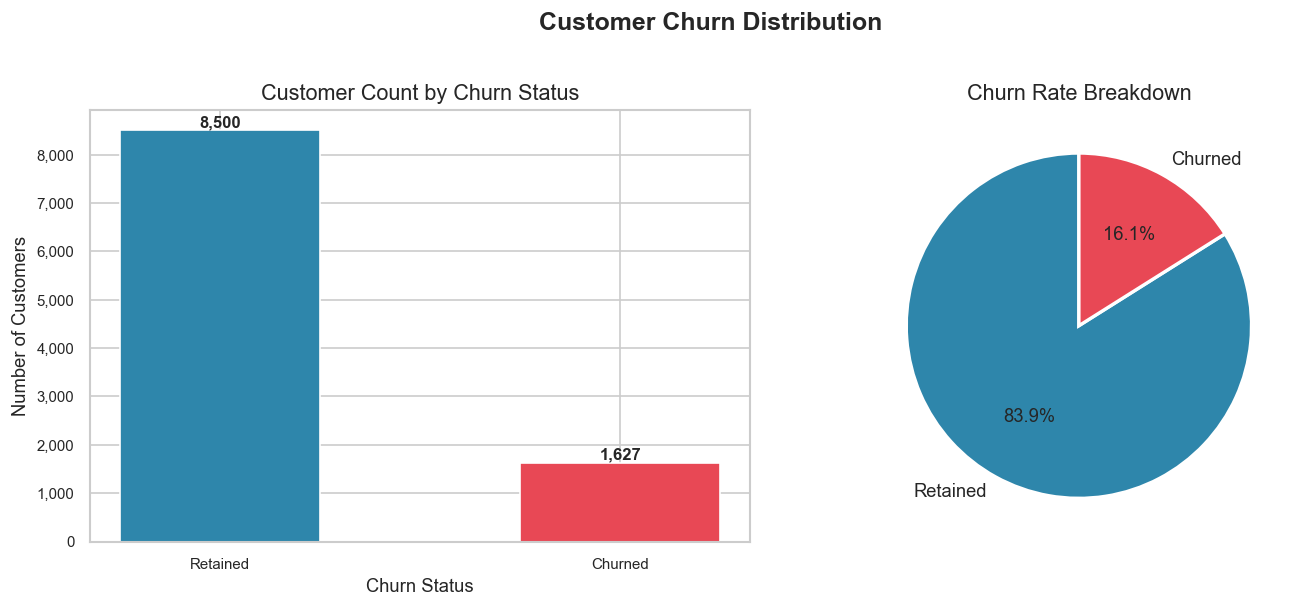

✅ Chart saved to outputs/figures/01_churn_distribution.png


In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Customer Churn Distribution", fontsize=15, fontweight="bold", y=1.01)

churn_counts = df["Churn_Label"].value_counts().reindex(["Retained", "Churned"])
bar_colours  = [COLOURS["retained"], COLOURS["churned"]]

# Bar chart
axes[0].bar(
    churn_counts.index, churn_counts.values,
    color=bar_colours, edgecolor="white", width=0.5
)
axes[0].set_title("Customer Count by Churn Status")
axes[0].set_xlabel("Churn Status")
axes[0].set_ylabel("Number of Customers")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, (val, colour) in enumerate(zip(churn_counts.values, bar_colours)):
    axes[0].text(i, val + 80, f"{val:,}", ha="center", fontsize=10, fontweight="bold")

# Pie chart
axes[1].pie(
    churn_counts.values,
    labels=churn_counts.index,
    colors=bar_colours,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11},
)
axes[1].set_title("Churn Rate Breakdown")

plt.tight_layout()
plt.savefig("../outputs/figures/01_churn_distribution.png", bbox_inches="tight")
plt.show()
print("✅ Chart saved to outputs/figures/01_churn_distribution.png")

## 📈 Numeric Distributions

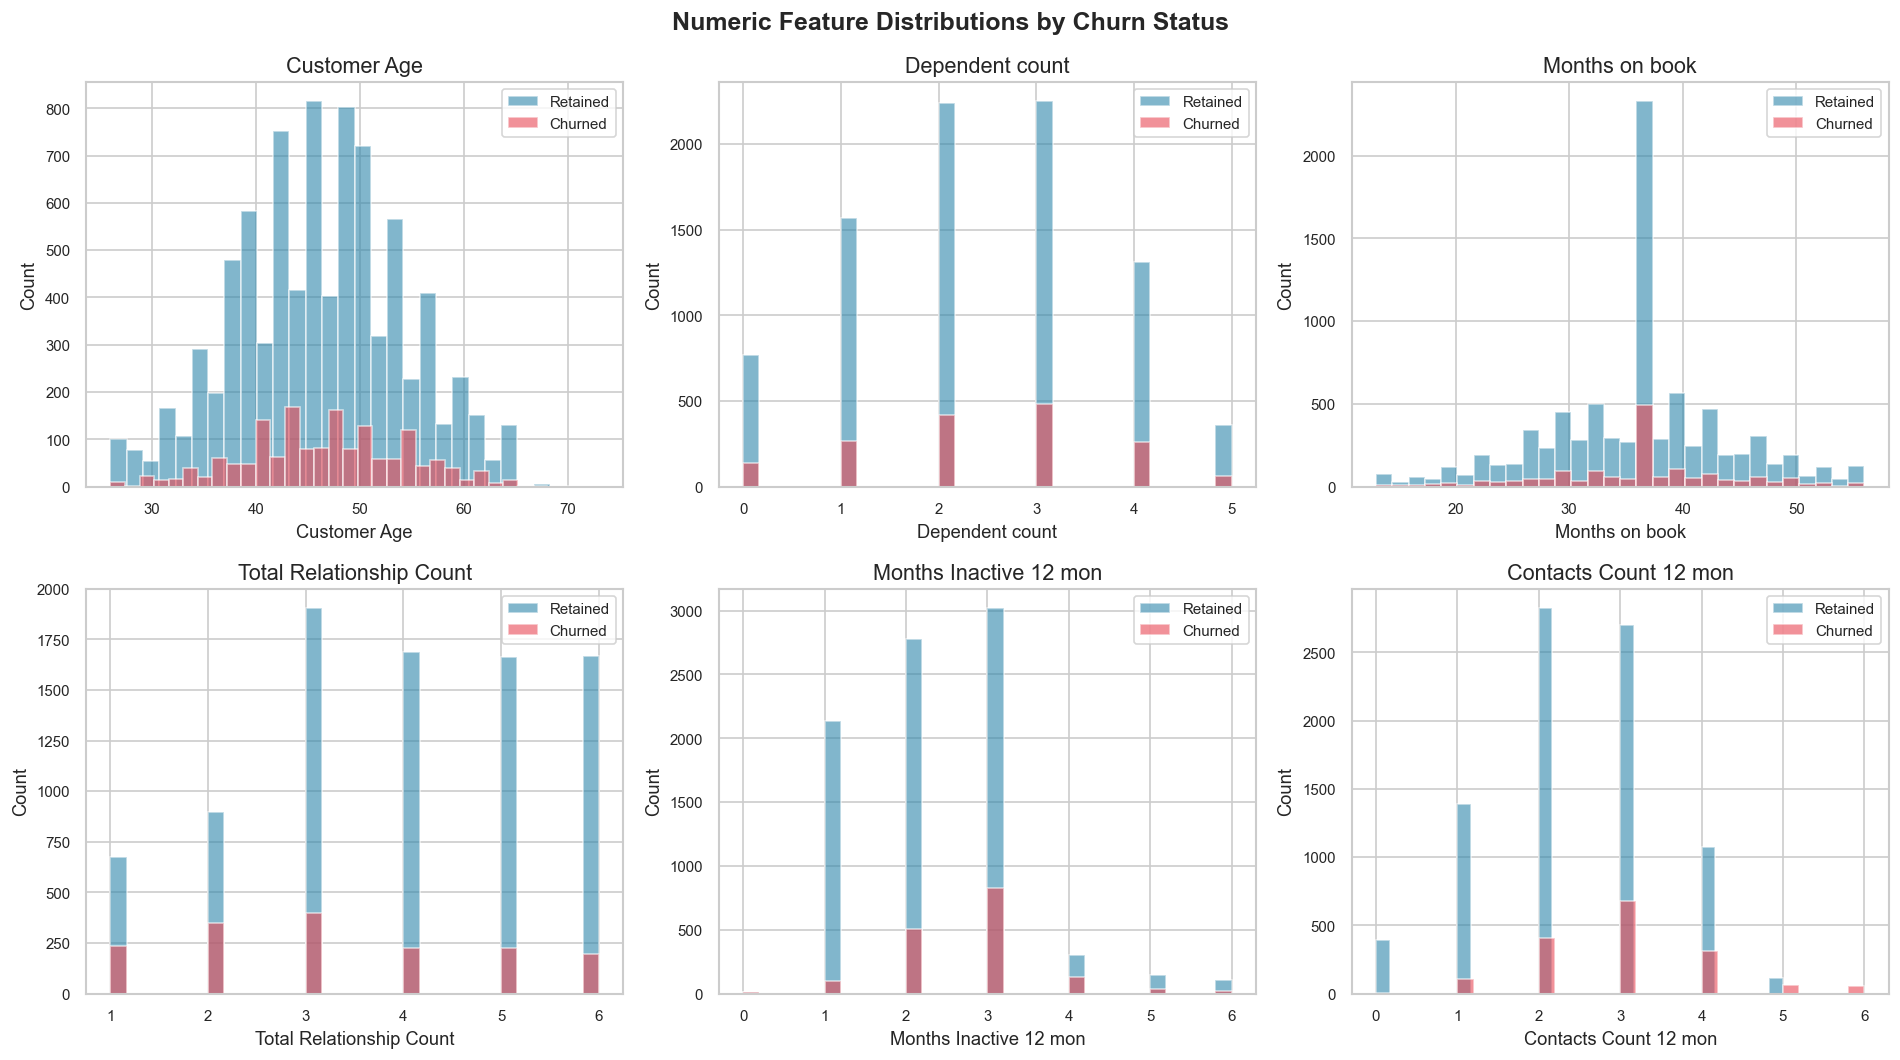

✅ Chart saved to outputs/figures/01_numeric_distributions.png


In [77]:
# Plot first 6 numeric columns in a 2×3 grid
plot_cols = numeric_cols[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Numeric Feature Distributions by Churn Status", fontsize=15, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    for label, colour in zip(["Retained", "Churned"], [COLOURS["retained"], COLOURS["churned"]]):
        subset = df[df["Churn_Label"] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, color=colour, label=label, edgecolor="white")
    axes[i].set_title(col.replace("_", " "))
    axes[i].set_xlabel(col.replace("_", " "))
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/01_numeric_distributions.png", bbox_inches="tight")
plt.show()
print("✅ Chart saved to outputs/figures/01_numeric_distributions.png")

## 📋 Categorical Breakdown

In [78]:
for col in categorical_cols:
    ct = (
        df.groupby([col, "Churn_Label"])
        .size()
        .reset_index(name="Count")
    )
    total = ct.groupby(col)["Count"].transform("sum")
    ct["Percentage"] = (ct["Count"] / total * 100).round(1)
    ct["Label"] = ct["Percentage"].astype(str) + "%"

    fig = px.bar(
        ct,
        x=col,
        y="Count",
        color="Churn_Label",
        barmode="group",
        text="Label",
        title=f"Churn Distribution by {col.replace('_', ' ')}",
        color_discrete_map={"Retained": COLOURS["retained"], "Churned": COLOURS["churned"]},
        template="plotly_white",
    )
    fig.update_traces(textposition="outside")
    fig.update_layout(
        legend_title="Churn Status",
        xaxis_title=col.replace("_", " "),
        yaxis_title="Number of Customers",
        title_font_size=14,
    )
    fig.show()

fig.write_html("../outputs/reports/01_categorical_breakdown.html")
print("✅ Interactive chart saved to outputs/reports/01_categorical_breakdown.html")

✅ Interactive chart saved to outputs/reports/01_categorical_breakdown.html


## 📝 Exploration Summary

In [79]:
_counts = df["Churn_Label"].value_counts()
_pct    = df["Churn_Label"].value_counts(normalize=True) * 100

retained_n = _counts.get("Retained", 0)
churned_n  = _counts.get("Churned", 0)
retained_p = _pct.get("Retained", 0.0)
churned_p  = _pct.get("Churned", 0.0)

summary = f"""
╔══════════════════════════════════════════════════════════════╗
║         STAGE 1 — EXPLORATION SUMMARY                       ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns{' ' * 19}║
║  Missing Values  : None                                      ║
║  Duplicates      : None                                      ║
║  Numeric Cols    : {len(numeric_cols)}{' ' * 43}║
║  Categorical Cols: {len(categorical_cols)}{' ' * 43}║
╠══════════════════════════════════════════════════════════════╣
║  TARGET VARIABLE — Attrition_Flag                            ║
║  Retained : {retained_n:,} customers  ({retained_p:.2f}%){' ' * 18}║
║  Churned  : {churned_n:,}  customers  ({churned_p:.2f}%){' ' * 19}║
║  Class Imbalance: YES — needs attention in modelling         ║
╠══════════════════════════════════════════════════════════════╣
║  KEY OBSERVATIONS                                            ║
║  - Most customers hold Blue card category                    ║
║  - Income skewed toward lower brackets                       ║
║  - Transaction count & amount differ notably by churn status ║
║  - Inactive months correlate with churn                      ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT STEP: Stage 2 — Data Cleaning & Transformation         ║
╚══════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║         STAGE 1 — EXPLORATION SUMMARY                       ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset Shape   : 10,127 rows × 21 columns                   ║
║  Missing Values  : None                                      ║
║  Duplicates      : None                                      ║
║  Numeric Cols    : 14                                           ║
║  Categorical Cols: 5                                           ║
╠══════════════════════════════════════════════════════════════╣
║  TARGET VARIABLE — Attrition_Flag                            ║
║  Retained : 8,500 customers  (83.93%)                  ║
║  Churned  : 1,627  customers  (16.07%)                   ║
║  Class Imbalance: YES — needs attention in modelling         ║
╠══════════════════════════════════════════════════════════════╣
║  KEY OBSERVATIONS                                            ║
║  - Most customers hold Blue